# 2. Exploratory Data Analysis (EDA) for Key Feature Exploration

### Outline of this notebook:  
* **Section 1:** Objective
* **Section 2:** Load Cleaned Dataset  
* **Section 3:** Loan Characteristics  
* **Section 4:** Borrower Characteristics  
* **Section 5:** EDA Summary  

---
## Section 1: Objective

This notebook focuses on **exploratory data analysis (EDA)** of key features that are most likely to drive default risk.

After initial data cleaning (e.g., removing leakage variables, dropping features with high missingness), the dataset still contains a large number of candidate variables. While machine learning models can handle many features, it is important to first build **economic intuition** about which variables are most relevant and how they relate to default outcomes.

In this notebook, we explore a set of **economically meaningful features** guided by standard credit risk intuition, including:
- 🔷 **Loan characteristics:** e.g. `loan_amnt`, `term`, `int_rate`, `installment`, `purpose`
- 🔷 **Borrower characteristics:**
  - **1. Ability to pay:** e.g. `annual_inc`, `emp_length`, `home_ownership`, `verification_status`, `dti`
  - **2. Credit history:** e.g. `delinq_2yrs`, `inq_last_6mths`, `pub_rec`, `total_acc`, `open_acc`
  - **3. Credit usage:** e.g. `revol_bal`, `revol_util`
  - **4. Creditworthiness (LC summary):** e.g. `grade`, `sub_grade`

The goal is not to finalize the feature set, but to:
- Identify **patterns and relationships** between features and default
- Understand **which variables are likely to be important drivers**
- Build intuition about how different dimensions of borrower risk interact

This analysis complements later **model-based feature selection** (e.g., LASSO, tree-based methods), helping ensure that the modeling stage is both data-driven and economically interpretable.

For visualization, we use plotting functions (`plot_dist_and_default`, `plot_hist_and_default`) defined in the `src` folder to systematically compare distributions and default rates across multiple characteristics.

---
## Section 2: Load Cleaned Dataset 

In [56]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))
from src.plot_utils import plot_dist_and_default, plot_hist_and_default

In [5]:
df_cleaned = pd.read_parquet("../data/processed/LendingClub_cleaned.parquet")

---
## Section 3: Loan Characteristics

### 🔷 3.1: Term

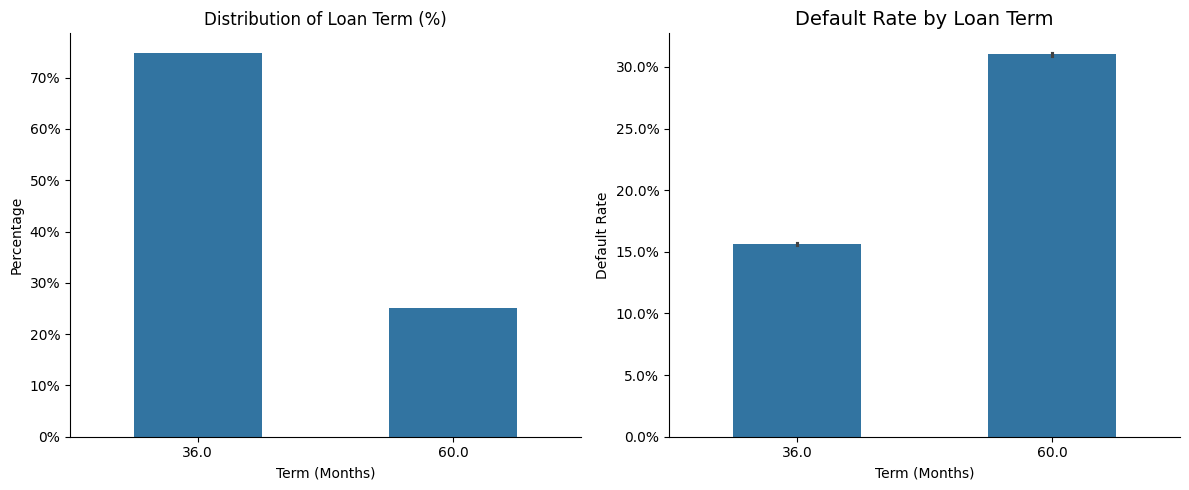

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Distribution (%)
term_pct = (
    df_cleaned['term']
    .value_counts(normalize=True)
    .sort_index()
    .reset_index()
)
term_pct.columns = ['term', 'percentage']

sns.barplot(
    data=term_pct,
    x='term',
    y='percentage',
    ax=axes[0],
    width=0.5          
    #color='#4C72B0'
)

axes[0].set_title("Distribution of Loan Term (%)", fontsize=12)
axes[0].set_xlabel("Term (Months)")
axes[0].set_ylabel("Percentage")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

# --- Default rate
sns.barplot(
    data=df_cleaned,
    x='term',
    y='default',
    estimator='mean',
    ax=axes[1],
    width=0.5         
    #color='#DD8452'
)

axes[1].set_title("Default Rate by Loan Term", fontsize=14)
axes[1].set_xlabel("Term (Months)")
axes[1].set_ylabel("Default Rate")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

# Clean up look
sns.despine()
plt.tight_layout()
plt.show()

### 🔷 3.2: Loan amount, interest rate, installment 

`installment` refers to the fixed monthly payment that a borrower must make to repay the loan over its term. It is determined at origination based on the loan amount, interest rate, and loan term (e.g., 36 or 60 months), using standard amortization. Each installment includes both principal and interest, and remains constant over time. Economically, it captures the borrower’s **monthly financial burden**, making it an important predictor of default risk since higher installments imply greater repayment pressure.

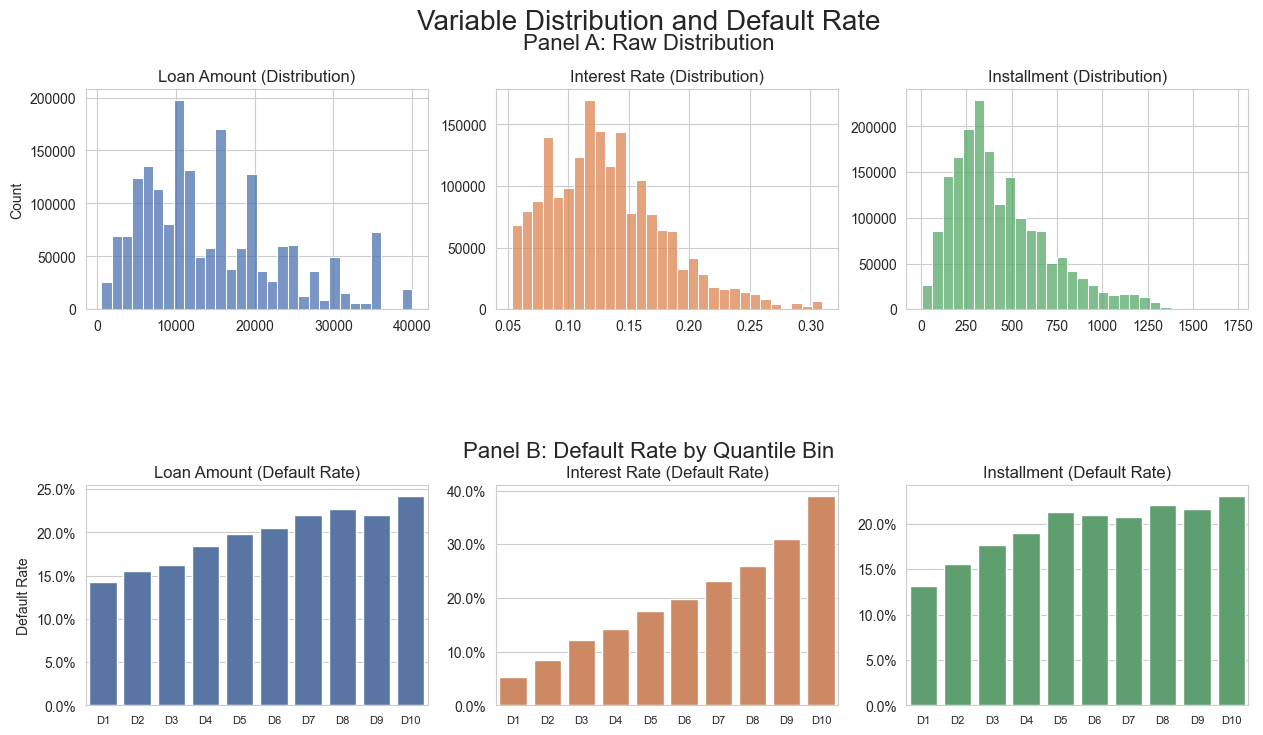

In [10]:
plot_hist_and_default(
    df=df_cleaned,
    var_list=['loan_amnt', 'int_rate', 'installment'],
    target='default',
    n_bins=10,
    var_labels={
        'loan_amnt': 'Loan Amount',
        'int_rate': 'Interest Rate',
        'installment': 'Installment'
    }
)

### 🔷 3.3: Loan Purpose

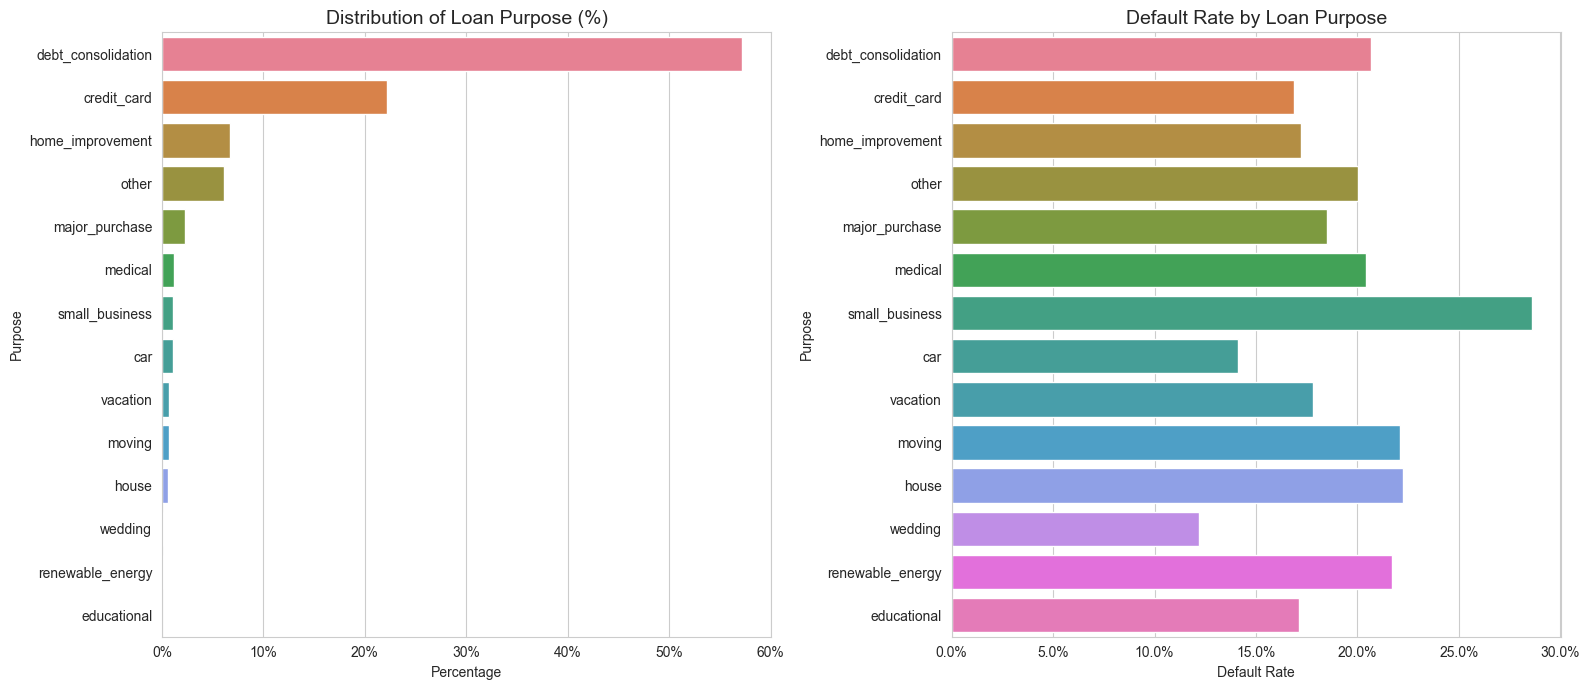

In [12]:
# Clean data
df_purpose = df_cleaned[['purpose', 'default']].dropna().copy()

# --- Distribution (%)
purpose_pct = (
    df_purpose['purpose']
    .value_counts(normalize=True)
    .rename('percentage')
    .reset_index()
    .rename(columns={'index': 'purpose'})
)

# --- Default rate
default_rate_purpose = (
    df_purpose.groupby('purpose', as_index=False)['default']
    .mean()
)

# Order by frequency
order = purpose_pct['purpose'].tolist()

# Create consistent color mapping
palette = sns.color_palette("husl", n_colors=len(order))
color_map = dict(zip(order, palette))

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Distribution
sns.barplot(
    data=purpose_pct,
    y='purpose',
    x='percentage',
    order=order,
    hue='purpose',
    palette=color_map,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Distribution of Loan Purpose (%)", fontsize=14)
axes[0].set_xlabel("Percentage", fontsize=10)
axes[0].set_ylabel("Purpose", fontsize=10)
axes[0].xaxis.set_major_formatter(PercentFormatter(1))

# 2. Default rate (FIXED: added hue)
sns.barplot(
    data=default_rate_purpose,
    y='purpose',
    x='default',
    order=order,
    hue='purpose',
    palette=color_map,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Default Rate by Loan Purpose", fontsize=14)
axes[1].set_xlabel("Default Rate", fontsize=10)
axes[1].set_ylabel("Purpose", fontsize=10)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

---
## Section 4: Borrower's Characteristics

### 🔷 4.1: Ability to Pay

In [15]:
df_cleaned['emp_length'].value_counts(dropna=False)

emp_length
10.0    611462
2.0     168545
0.5     153732
3.0     149311
1.0     122964
NaN     117261
5.0     115894
4.0     112236
6.0      85369
8.0      78659
7.0      78153
9.0      67179
Name: count, dtype: int64

/Users/yukyungkoh/Desktop/1_Post-PhD/8_Projects/credit-risk-modeling/src/plot_utils.py:157: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df['_plot_var'] = plot_df[var].astype('object').fillna('Missing')


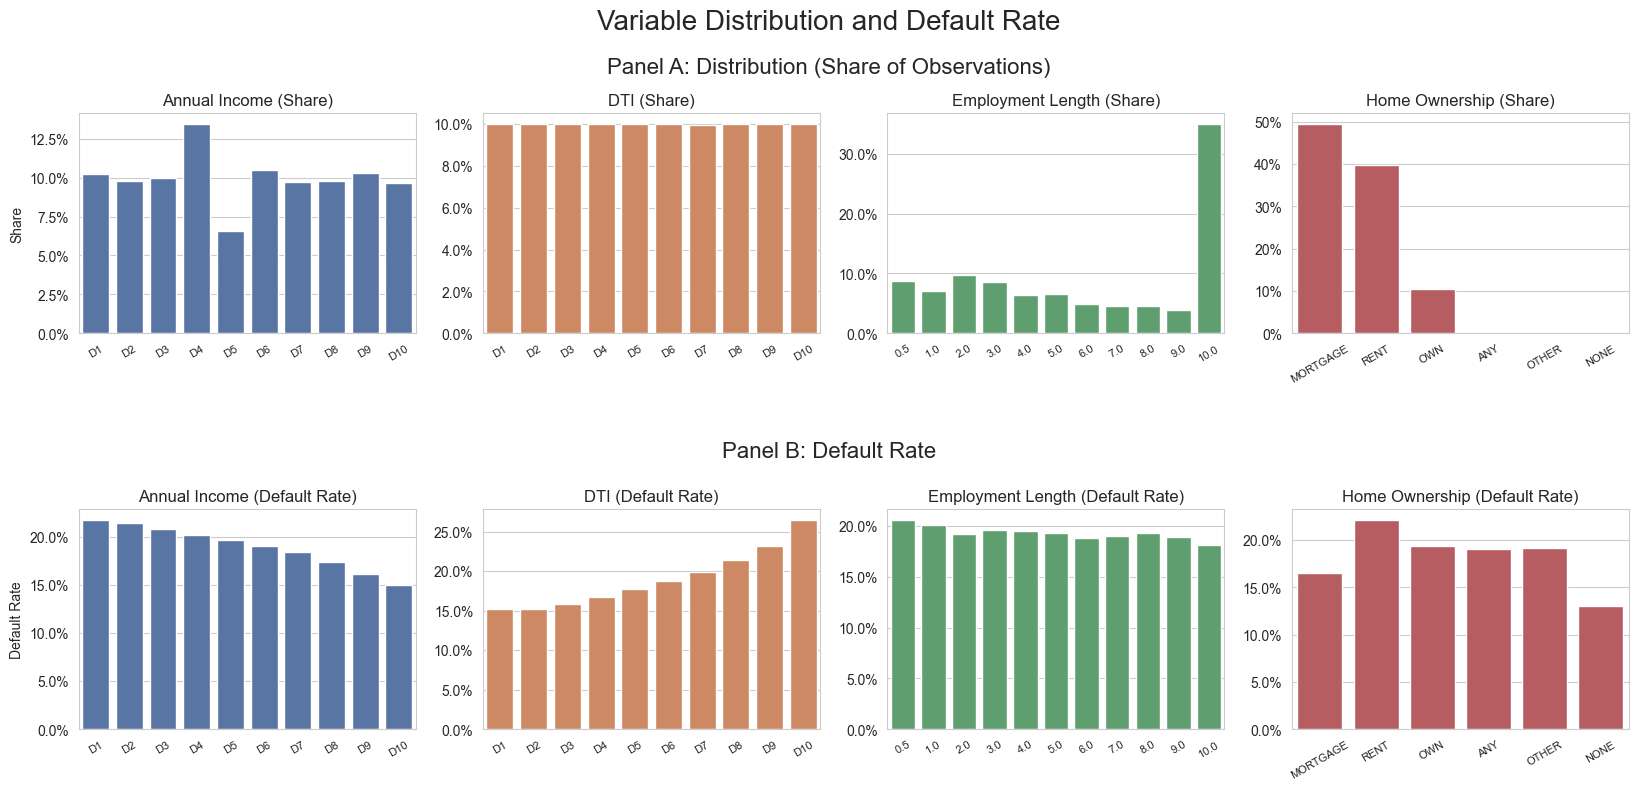

In [16]:
# -----------------------------
# 1. Clean variables before plotting
# -----------------------------
### Numeric
df_cleaned['annual_inc'] = pd.to_numeric(df_cleaned['annual_inc'], errors='coerce')
df_cleaned['dti'] = pd.to_numeric(df_cleaned['dti'], errors='coerce')

### Categorical
# Define correct order for employment length
emp_order = [0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Drop missing only for plotting variable
df_cleaned['emp_length_plot'] = df_cleaned['emp_length']

# Convert to ordered categorical
df_cleaned['emp_length_plot'] = pd.Categorical(
    df_cleaned['emp_length_plot'],
    categories=emp_order,
    ordered=True
)
# home ownership: optional cleanup
df_cleaned['home_ownership'] = df_cleaned['home_ownership'].astype('object')

df_plot = df_cleaned.dropna(subset=['emp_length_plot'])

# -----------------------------
# 2. Plot
# -----------------------------
plot_dist_and_default(
    df=df_plot,
    var_list=['annual_inc', 'dti', 'emp_length_plot', 'home_ownership'],
    target='default',
    n_bins=10,
    var_labels={
        'annual_inc': 'Annual Income',
        'dti': 'DTI',
        'emp_length_plot': 'Employment Length',
        'home_ownership': 'Home Ownership'
    },
    rotate_x=30
)

### 🔷 4.2: Credit history

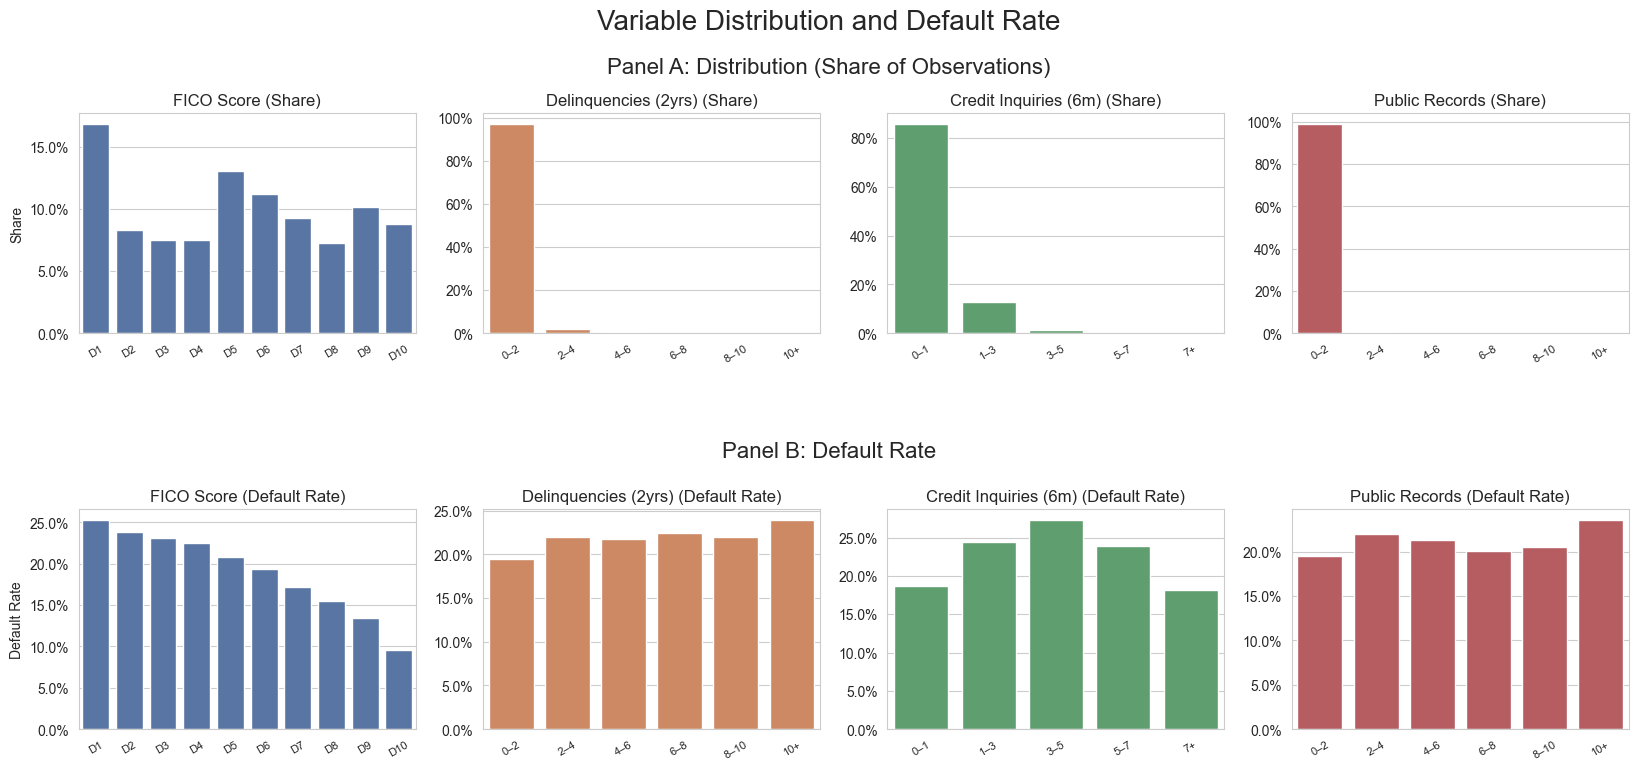

In [18]:
# -----------------------------
# 1. Clean variables before plotting
# -----------------------------
cols = ['fico_range_low', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'default']
for col in cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# FICO: deciles -> D1 ... D10
df_cleaned['fico_bin'] = pd.qcut(
    df_cleaned['fico_range_low'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop'
)

### Create decile bins (with labels)
# Delinquencies: interval bins
delinq_bins = [-1, 2, 4, 6, 8, 10, float('inf')]
delinq_labels = ['0–2', '2–4', '4–6', '6–8', '8–10', '10+']

df_cleaned['delinq_bin'] = pd.cut(
    df_cleaned['delinq_2yrs'],
    bins=delinq_bins,
    labels=delinq_labels
)

# Credit inquiries: interval bins
inq_bins = [-1, 1, 3, 5, 7, float('inf')]
inq_labels = ['0–1', '1–3', '3–5', '5–7', '7+']

df_cleaned['inq_bin'] = pd.cut(
    df_cleaned['inq_last_6mths'],
    bins=inq_bins,
    labels=inq_labels
)

# Public records: interval bins
pubrec_bins = [-1, 2, 4, 6, 8, 10, float('inf')]
pubrec_labels = ['0–2', '2–4', '4–6', '6–8', '8–10', '10+']

df_cleaned['pubrec_bin'] = pd.cut(
    df_cleaned['pub_rec'],
    bins=pubrec_bins,
    labels=pubrec_labels
)

# -----------------------------
# 2. Plot
# -----------------------------
plot_dist_and_default(
    df=df_cleaned,
    var_list=['fico_bin', 'delinq_bin', 'inq_bin', 'pubrec_bin'],
    target='default',
    cat_orders={
        'fico_bin': [f'D{i}' for i in range(1, 11)],
        'delinq_bin': delinq_labels,
        'inq_bin': inq_labels,
        'pubrec_bin': pubrec_labels
    },
    var_labels={
        'fico_bin': 'FICO Score',
        'delinq_bin': 'Delinquencies (2yrs)',
        'inq_bin': 'Credit Inquiries (6m)',
        'pubrec_bin': 'Public Records'
    },
    rotate_x=30
)


### 🔷 4.3: Credit usage

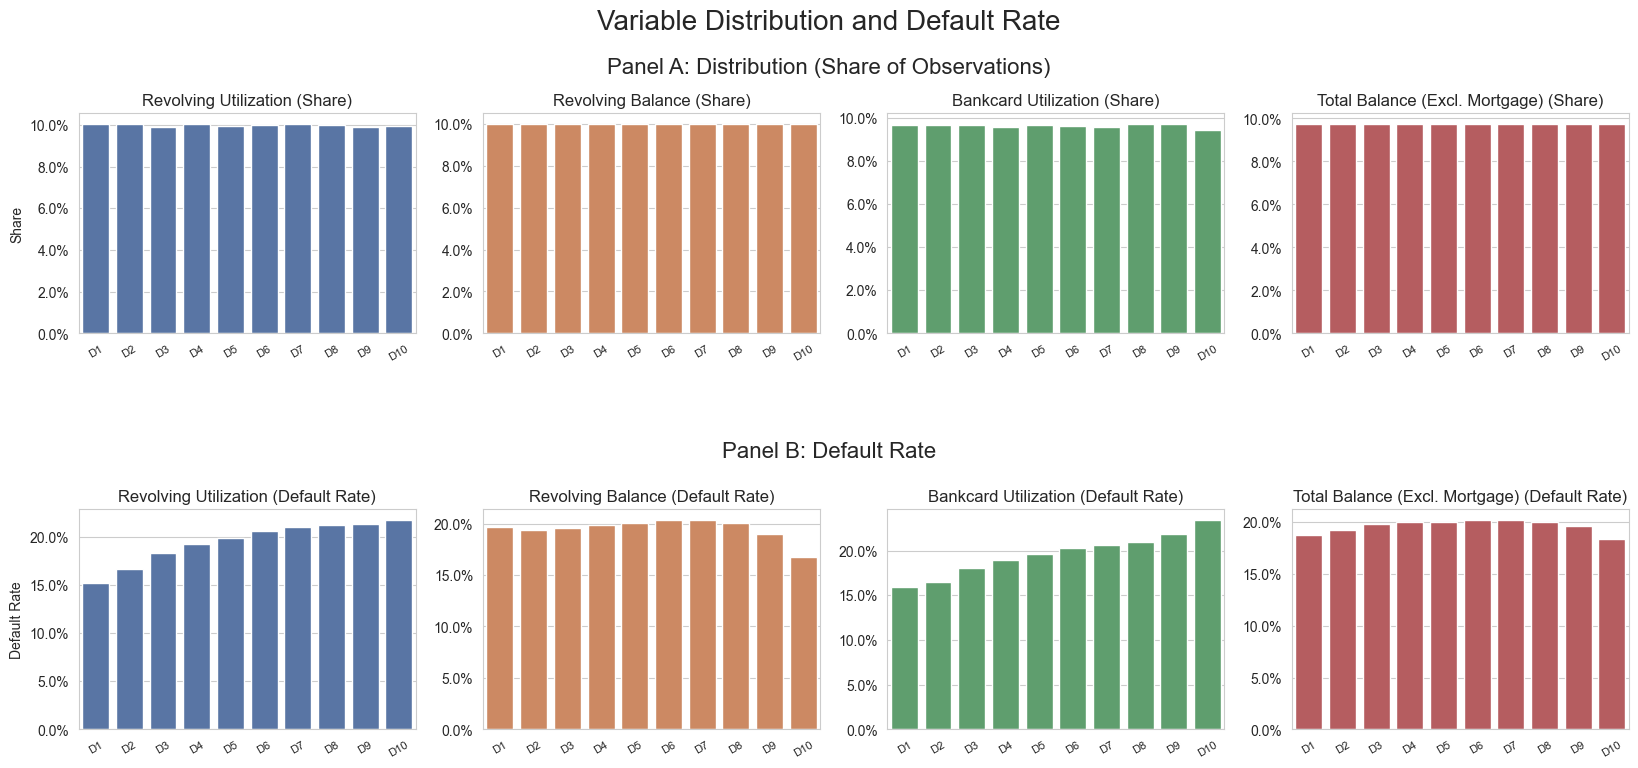

In [20]:
# -----------------------------
# 1. Clean variables before plotting
# -----------------------------
cols = ['revol_util', 'revol_bal', 'bc_util', 'total_bal_ex_mort', 'default']
for col in cols:
    if col in ['revol_util', 'bc_util']:
        df_cleaned[col] = (
            df_cleaned[col]
            .astype(str)
            .str.replace('%', '', regex=False)
            .str.strip()
        )
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')


### Create decile bins (with labels)
usage_vars = ['revol_util', 'revol_bal', 'bc_util', 'total_bal_ex_mort']
bin_names = ['revol_util_bin', 'revol_bal_bin', 'bc_util_bin', 'total_bal_ex_mort_bin']

for var, bin_var in zip(usage_vars, bin_names):
    df_cleaned[bin_var] = pd.qcut(
        df_cleaned[var],
        q=10,
        labels=[f'D{i}' for i in range(1, 11)],
        duplicates='drop'
    )

# -----------------------------
# 2. Plot
# -----------------------------
plot_dist_and_default(
    df=df_cleaned,
    var_list=['revol_util_bin', 'revol_bal_bin', 'bc_util_bin', 'total_bal_ex_mort_bin'],
    target='default',
    cat_orders={
        'revol_util_bin': [f'D{i}' for i in range(1, 11)],
        'revol_bal_bin': [f'D{i}' for i in range(1, 11)],
        'bc_util_bin': [f'D{i}' for i in range(1, 11)],
        'total_bal_ex_mort_bin': [f'D{i}' for i in range(1, 11)]
    },
    var_labels={
        'revol_util_bin': 'Revolving Utilization',
        'revol_bal_bin': 'Revolving Balance',
        'bc_util_bin': 'Bankcard Utilization',
        'total_bal_ex_mort_bin': 'Total Balance (Excl. Mortgage)'
    },
    rotate_x=30
)


#### 🔷 4.4: Creditworthiness (LC summary)

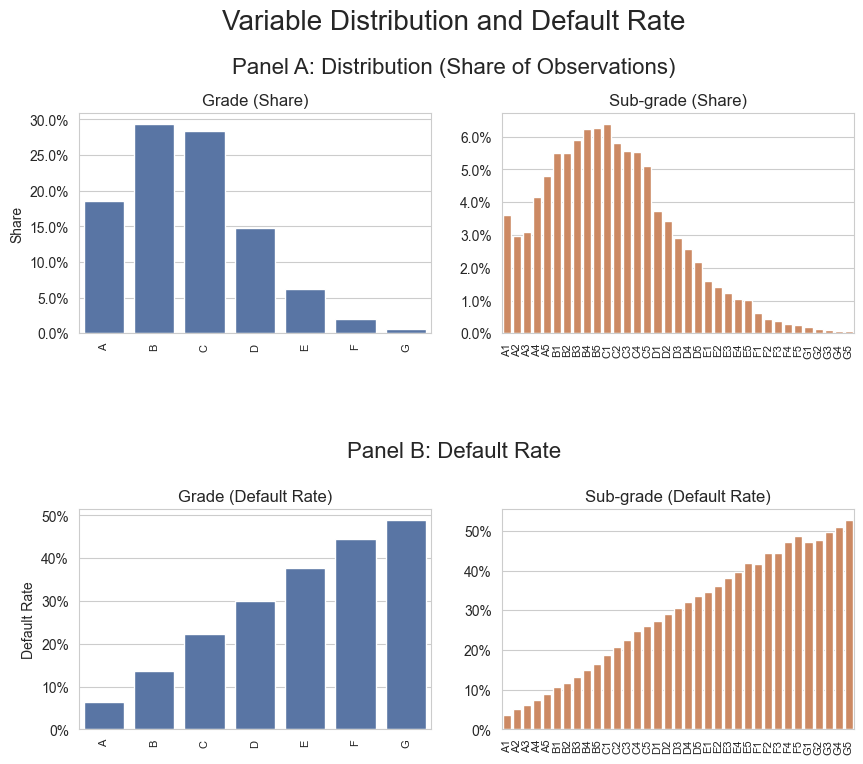

In [22]:
# -----------------------------
# 1. Prepare data
# -----------------------------
df_cleaned['grade'] = df_cleaned['grade'].astype('object')
df_cleaned['sub_grade'] = df_cleaned['sub_grade'].astype('object')
df_cleaned['default'] = pd.to_numeric(df_cleaned['default'], errors='coerce')

# Grade order: A -> G
grade_order = sorted(df_cleaned['grade'].dropna().unique())

# Sub-grade order: A1 -> G5
subgrade_order = sorted(df_cleaned['sub_grade'].dropna().unique())

# -----------------------------
# 2. Plot
# -----------------------------
plot_dist_and_default(
    df=df_cleaned,
    var_list=['grade', 'sub_grade'],
    target='default',
    cat_orders={
        'grade': grade_order,
        'sub_grade': subgrade_order
    },
    var_labels={
        'grade': 'Grade',
        'sub_grade': 'Sub-grade'
    },
    rotate_x=90
)

---
## Section 5: Correlations

In [24]:
df_cleaned.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'fico_range_low', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'acc_now_delinq', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_t

In [44]:
# Exclude categorical and non-numeric identifier-like variables
categorical_cols = [
    'grade', 'sub_grade', 
    'home_ownership', 'verification_status',
    'purpose',
    'initial_list_status', 'application_type'
]
exclude_cols = categorical_cols + ['zip_code', 'addr_state', 'issue_d', 'default', 'emp_length_plot']

# Keep only remaining numeric variables
corr_vars = [col for col in df_cleaned.columns if col not in exclude_cols]
corr_vars

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'acc_now_delinq',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_rev_accts',
 'num_rev_tl_bal_gt_0',
 'num_sats',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'num_tl_90g_dpd_24m',
 'num_tl_op_past_12m',
 'pct_tl_nvr_dlq',
 'percent_bc_gt_75',
 'pub_rec_bankruptcies',
 'tax_liens',
 'tot_hi_cred_lim',
 'total_bal_ex_mort',
 'total_bc_limit',
 'total_il_high_credit_limit',
 'credit_age',
 'fico_bin',
 'delinq_bin',
 'inq_b

In [52]:
# Keep only numeric columns AFTER exclusions
corr_df = df_cleaned.drop(columns=exclude_cols)

corr_df = corr_df.select_dtypes(include='number')

corr_matrix = corr_df.corr()
corr_df.dtypes[corr_df.dtypes == 'object']

Series([], dtype: object)

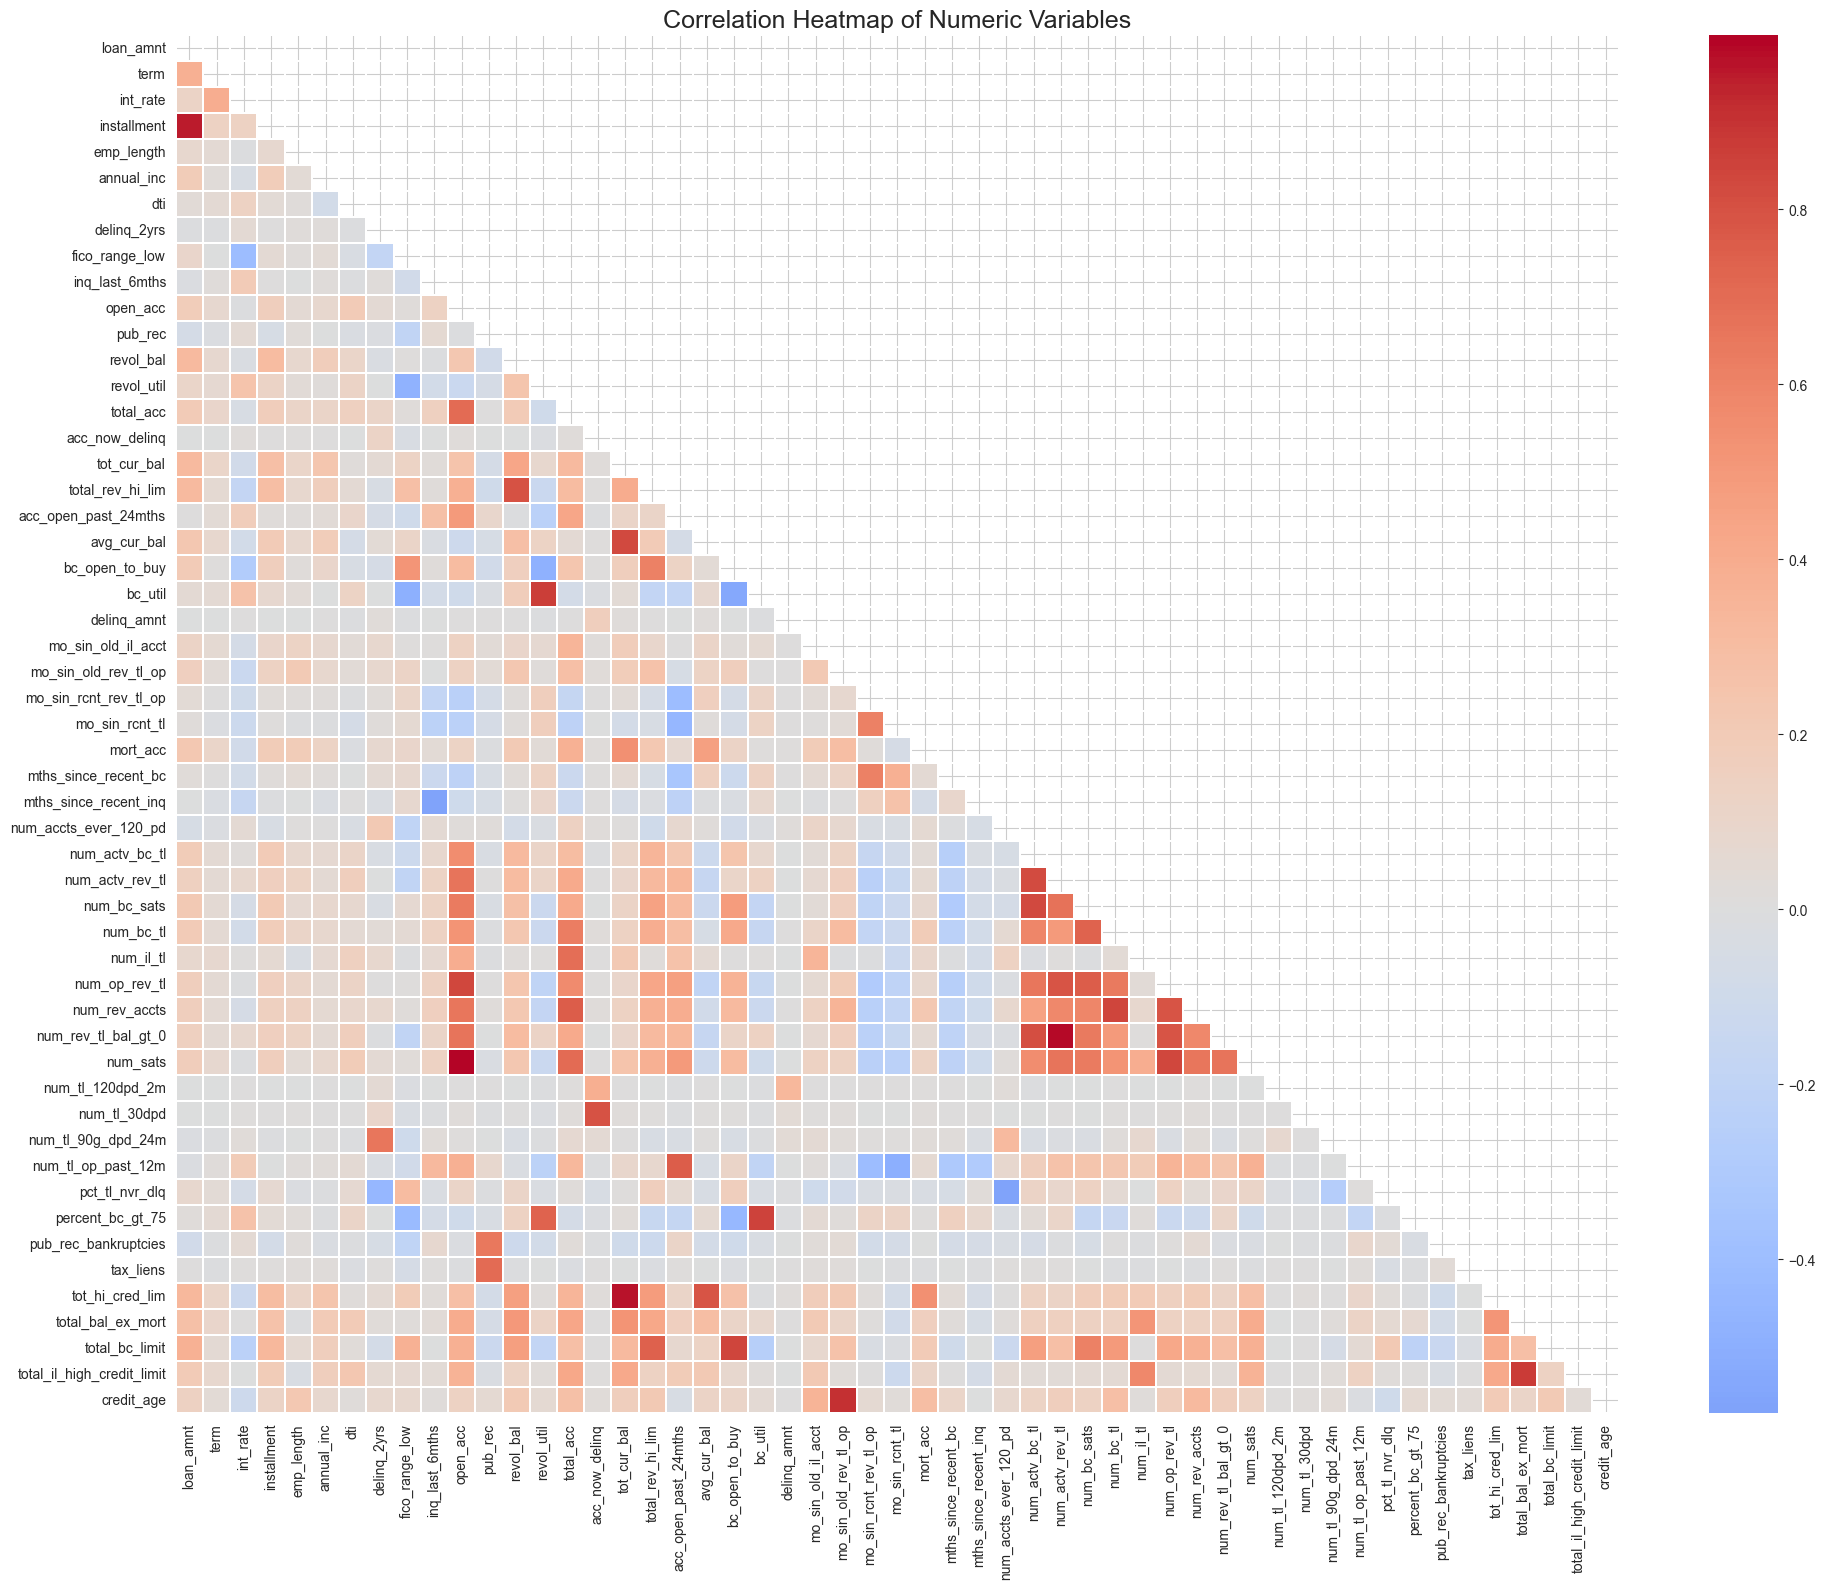

In [58]:
# Correlation matrix
corr_matrix = corr_df.corr()

# Create mask for upper triangle (optional: cleaner visualization)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    square=False
)

plt.title('Correlation Heatmap of Numeric Variables', fontsize=18)
plt.tight_layout()
plt.show()